# Lohitha — Step 3

**Calibo AI Academy — Phase 1, Mini Use Case 01**
**Prepared by: Lohitha**

In [1]:
# Import the libraries needed for data handling, math, and plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean grid style and a readable default figure size for every chart.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Show large numbers with thousands separators instead of scientific notation.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
# Load the retail sales dataset from the project folder (relative path).
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")
print(df.head())


  transaction_id        date store_id  ... unit_price   revenue discount_pct
0      TXN000001  2026-01-01      S01  ...   3,075.46  5,843.37            5
1      TXN000002  2026-01-01      S01  ...  11,598.06 11,598.06            0
2      TXN000003  2026-01-01      S01  ...   5,738.37 15,493.60           10
3      TXN000004  2026-01-01      S01  ...   3,281.28  9,351.65            5
4      TXN000005  2026-01-01      S01  ...   1,917.14  1,917.14            0

[5 rows x 10 columns]


In [3]:
# Convert the date column into a true datetime type so later steps can use it.
df["date"] = pd.to_datetime(df["date"])
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("date column dtype after conversion:", df["date"].dtype)


Date range: 2026-01-01 to 2026-06-30
date column dtype after conversion: datetime64[us]


## Step 3 — Top and Bottom Products by Category
**Owner: Lohitha**

For every category, we rank products by total 6-month revenue and identify the top 2 and bottom 2
performers, to see which specific products are driving or dragging category results.


In [4]:
# For each category, rank its 5 products by total revenue and keep the top 2 / bottom 2.
rows = []
for category in sorted(df["category"].unique()):
    prod_rev = (
        df[df["category"] == category]
        .groupby("product_name")["revenue"]
        .sum()
        .sort_values(ascending=False)
    )
    top2 = prod_rev.head(2)
    bottom2 = prod_rev.tail(2)
    for product, revenue in top2.items():
        rows.append({"Category": category, "Rank Type": "Top", "Product": product, "Total Revenue": revenue})
    for product, revenue in bottom2.items():
        rows.append({"Category": category, "Rank Type": "Bottom", "Product": product, "Total Revenue": revenue})

top_bottom_summary = pd.DataFrame(rows)
top_bottom_summary


In [5]:
# Across every category, which specific products are the weakest overall?
weakest_products = top_bottom_summary[top_bottom_summary["Rank Type"] == "Bottom"].sort_values("Total Revenue")
print("Lowest-revenue products overall (across all categories):")
print(weakest_products.head(5).to_string(index=False))


Lowest-revenue products overall (across all categories):
     Category Rank Type     Product  Total Revenue
Personal Care    Bottom   Sunscreen   7,593,863.45
Personal Care    Bottom  Toothpaste   7,768,812.48
      Grocery    Bottom Sugar (1kg)   8,377,786.05
      Grocery    Bottom    Oil (1L)   8,431,630.01
      Apparel    Bottom       Kurta  13,606,747.03


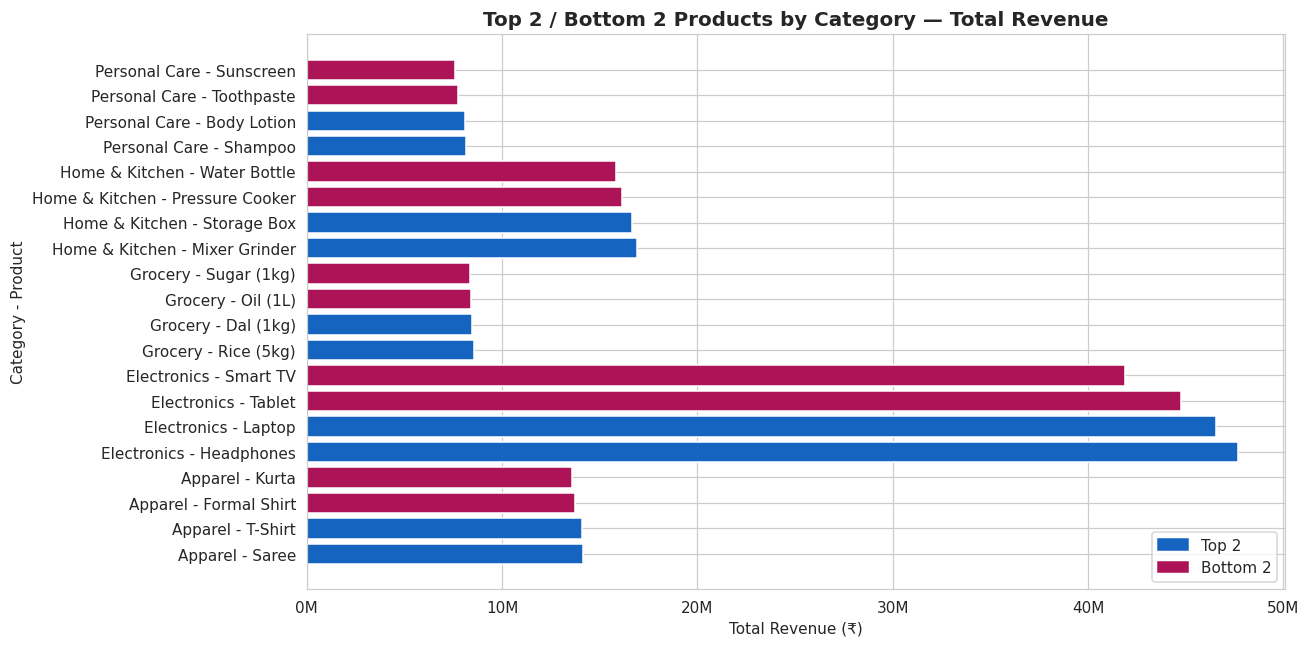

In [6]:
# Chart: total revenue for the top 2 / bottom 2 products in each category (pink + blue only).
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = top_bottom_summary.copy()
plot_df["label"] = plot_df["Category"] + " - " + plot_df["Product"]
colors = plot_df["Rank Type"].map({"Top": "#1565c0", "Bottom": "#ad1457"})
ax.barh(plot_df["label"], plot_df["Total Revenue"], color=colors)
ax.set_title("Top 2 / Bottom 2 Products by Category — Total Revenue")
ax.set_xlabel("Total Revenue (\u20b9)")
ax.set_ylabel("Category - Product")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#1565c0", label="Top 2"), Patch(color="#ad1457", label="Bottom 2")], loc="lower right")
plt.tight_layout()
plt.show()


### Business Interpretation
Within every category, revenue is fairly evenly spread across its five products — there is no single
product collapsing on its own inside a category. That means the **Electronics decline (from Step 2)
is a category-wide problem, not a single weak SKU**: its softest performers contribute to the drop,
but so does every other product in the category.

The weakest individual products chain-wide sit mainly in **Personal Care and Grocery** — categories
that are already low-revenue overall, so their bottom performers are a lower business priority than
Electronics' decline. For the supplier review, the most useful product-level detail to raise is which
specific Electronics products are softest, since that category is where the revenue is actually at
stake.